# Lesson 10 — NN Surrogate with MC Dropout

## Method A — Gal & Ghahramani (2016)

A standard neural network gives one prediction per input — no uncertainty. **MC Dropout** fixes this with a single change: keep dropout active at inference time and run T forward passes.

$$\mu(x) = \frac{1}{T}\sum_{t=1}^T f_\theta^{(t)}(x), \qquad \sigma^2(x) = \frac{1}{T}\sum_{t=1}^T \left(f_\theta^{(t)}(x) - \mu(x)\right)^2$$

Each $f_\theta^{(t)}$ is a different stochastic forward pass — different neurons are zeroed each time.

**Architecture:**
```
Input(d) → Linear(64) → ReLU → Dropout(0.1)
         → Linear(64) → ReLU → Dropout(0.1)
         → Linear(1)
```
**The only implementation difference from Lesson 9:** add `nn.Dropout(0.1)` and call `model.train()` at inference.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.stats import norm

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
rng = np.random.default_rng(RANDOM_SEED)

## Model definitions and helpers

In [2]:
def forrester(x):
    x = np.asarray(x).ravel()
    return (6*x - 2)**2 * np.sin(12*x - 4)

class MCDropoutMLP(nn.Module):
    """
    MC Dropout surrogate — Method A (Gal & Ghahramani 2016).
    Call model.train() at inference to keep dropout active.
    """
    def __init__(self, input_dim=1, hidden=64, dropout_rate=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x)

    def mc_predict(self, x, n_passes=50):
        """T stochastic forward passes → (mu, std) in network output space."""
        self.train()                   # keep dropout ON — this is the key line
        with torch.no_grad():
            preds = torch.stack([self(x) for _ in range(n_passes)])
        return preds.mean(0).squeeze(), preds.std(0).squeeze()

class MLP(nn.Module):
    def __init__(self, input_dim=1, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),    nn.ReLU(),
            nn.Linear(hidden, 1),
        )
    def forward(self, x): return self.net(x)

def train_model(model, X_tr, y_tr, n_epochs=3000, lr=1e-3):
    opt, loss_fn, losses = optim.Adam(model.parameters(), lr=lr), nn.MSELoss(), []
    for _ in range(n_epochs):
        model.train()
        opt.zero_grad()
        loss = loss_fn(model(X_tr).squeeze(), y_tr)
        loss.backward(); opt.step()
        losses.append(loss.item())
    return losses

def to_tensor(arr): return torch.from_numpy(arr.astype(np.float32))
def acq_ei(mu, std, f_best, xi=0.01):
    Z = (f_best - xi - mu) / (std + 1e-9)
    return np.maximum((f_best - xi - mu) * norm.cdf(Z) + std * norm.pdf(Z), 0)

print("Definitions ready.")

Definitions ready.


## Training data and model

In [3]:
n_train = 15
X_np    = rng.uniform(0, 1, (n_train, 1)).astype(np.float32)
y_np    = forrester(X_np).astype(np.float32)

Xm, Xs = float(X_np.mean()), float(X_np.std())
ym, ys = float(y_np.mean()), float(y_np.std())

X_tr = to_tensor((X_np - Xm) / Xs)
y_tr = to_tensor((y_np - ym) / ys)

x_dense   = np.linspace(0, 1, 300).astype(np.float32)
xs        = x_dense.squeeze()
y_true    = forrester(xs)
x_dense_t = to_tensor((x_dense.reshape(-1, 1) - Xm) / Xs)

torch.manual_seed(RANDOM_SEED)
model = MCDropoutMLP(input_dim=1, hidden=64, dropout_rate=0.1)
losses = train_model(model, X_tr, y_tr, n_epochs=3000)
print(f"Training done. Final loss: {losses[-1]:.6f}")

N_PASSES = 50
mu_s, std_s = model.mc_predict(x_dense_t, n_passes=N_PASSES)
mu_mc  = mu_s.numpy()  * ys + ym
std_mc = std_s.numpy() * ys
print(f"MC Dropout uncertainty range: [{std_mc.min():.3f}, {std_mc.max():.3f}]")

Training done. Final loss: 0.020469
MC Dropout uncertainty range: [0.056, 1.851]


## Part 1 — eval() vs train(): the entire MC Dropout mechanism

`nn.Dropout` behaves differently in the two modes:
- `model.eval()` → dropout is **disabled** → every call returns exactly the same output
- `model.train()` → dropout is **active** → each call randomly zeros different neurons → different output

MC Dropout exploits this: deliberately call `model.train()` at inference and run T passes to sample from the approximate posterior.

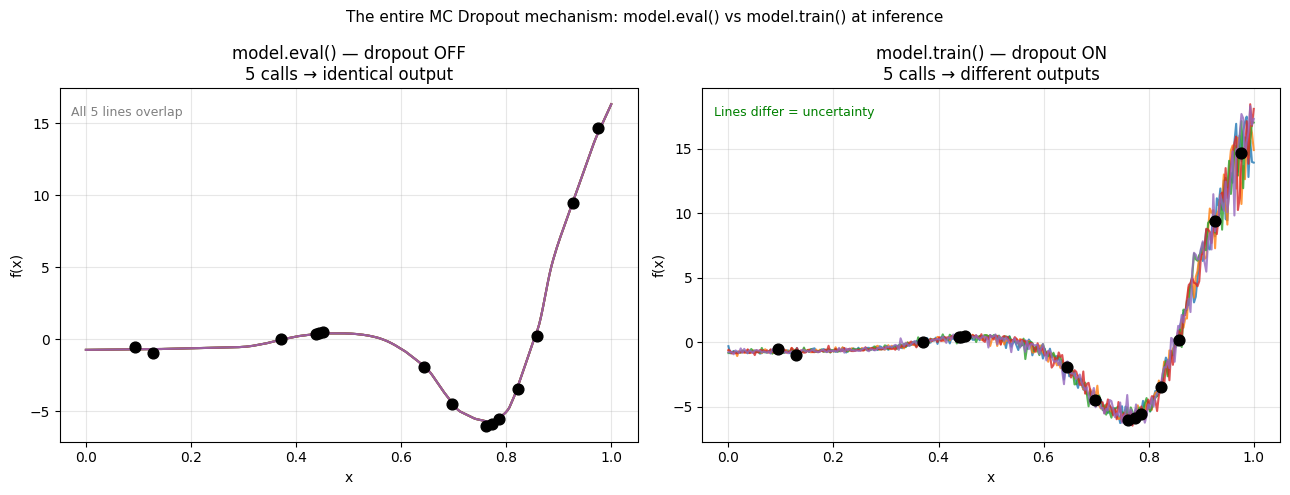

In [4]:
model.eval()
preds_eval = []
for _ in range(5):
    with torch.no_grad():
        preds_eval.append(model(x_dense_t).squeeze().numpy() * ys + ym)

model.train()   # MC Dropout mode
preds_train = []
for _ in range(5):
    with torch.no_grad():
        preds_train.append(model(x_dense_t).squeeze().numpy() * ys + ym)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for p in preds_eval:
    axes[0].plot(xs, p, linewidth=1.5, alpha=0.8)
axes[0].scatter(X_np.squeeze(), y_np, color="black", s=60, zorder=5)
axes[0].set_title("model.eval() — dropout OFF\n5 calls → identical output")
axes[0].set_xlabel("x"); axes[0].set_ylabel("f(x)"); axes[0].grid(True, alpha=0.3)
axes[0].text(0.02, 0.95, "All 5 lines overlap", transform=axes[0].transAxes,
             fontsize=9, color="gray", va="top")

for p in preds_train:
    axes[1].plot(xs, p, linewidth=1.5, alpha=0.8)
axes[1].scatter(X_np.squeeze(), y_np, color="black", s=60, zorder=5)
axes[1].set_title("model.train() — dropout ON\n5 calls → different outputs")
axes[1].set_xlabel("x"); axes[1].set_ylabel("f(x)"); axes[1].grid(True, alpha=0.3)
axes[1].text(0.02, 0.95, "Lines differ = uncertainty", transform=axes[1].transAxes,
             fontsize=9, color="green", va="top")

plt.suptitle("The entire MC Dropout mechanism: model.eval() vs model.train() at inference",
             fontsize=11)
plt.tight_layout()
plt.show()

**Try it:** Change `dropout_rate=0.1` to `dropout_rate=0.5` in `MCDropoutMLP`. The lines in the right panel will spread further apart — more dropout = more uncertainty per pass.

## Part 2 — 50 MC passes

With T=50 passes we get a smooth estimate of μ and σ. Each thin line is one stochastic forward pass. The spread of those lines at each x is σ(x).

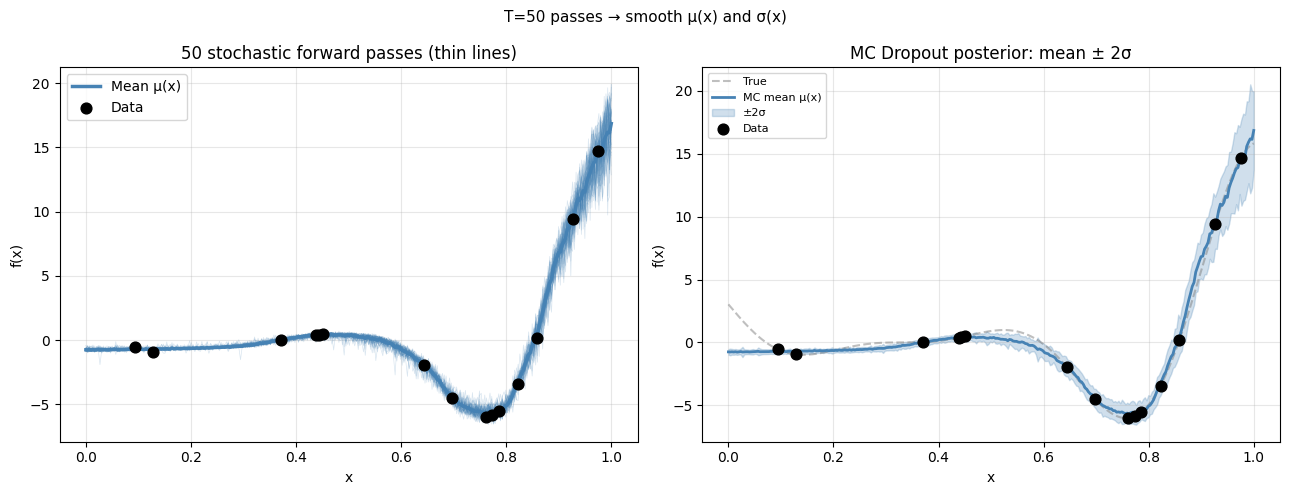

In [5]:
model.train()
all_passes = []
with torch.no_grad():
    for _ in range(N_PASSES):
        all_passes.append(model(x_dense_t).squeeze().numpy() * ys + ym)
all_passes = np.array(all_passes)

mu_all  = all_passes.mean(0)
std_all = all_passes.std(0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for p in all_passes:
    axes[0].plot(xs, p, color="steelblue", linewidth=0.5, alpha=0.2)
axes[0].plot(xs, mu_all, color="steelblue", linewidth=2.5, label="Mean μ(x)")
axes[0].scatter(X_np.squeeze(), y_np, color="black", s=60, zorder=5, label="Data")
axes[0].set_title(f"{N_PASSES} stochastic forward passes (thin lines)")
axes[0].set_xlabel("x"); axes[0].set_ylabel("f(x)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(xs, y_true, color="gray", linestyle="--", linewidth=1.5, alpha=0.5, label="True")
axes[1].plot(xs, mu_all, color="steelblue", linewidth=2, label="MC mean μ(x)")
axes[1].fill_between(xs, mu_all-2*std_all, mu_all+2*std_all,
                     alpha=0.25, color="steelblue", label="±2σ")
axes[1].scatter(X_np.squeeze(), y_np, color="black", s=60, zorder=5, label="Data")
axes[1].set_title("MC Dropout posterior: mean ± 2σ")
axes[1].set_xlabel("x"); axes[1].set_ylabel("f(x)")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.suptitle(f"T={N_PASSES} passes → smooth μ(x) and σ(x)", fontsize=11)
plt.tight_layout()
plt.show()

**Try it:** Change `N_PASSES = 5` above. Is σ still smooth? Try `N_PASSES = 200`. Is it noticeably better?

## Part 3 — Uncertainty scales with data sparsity

A well-calibrated surrogate should be **confident near training data** and **uncertain in gaps**. The black tick marks below show training point locations.

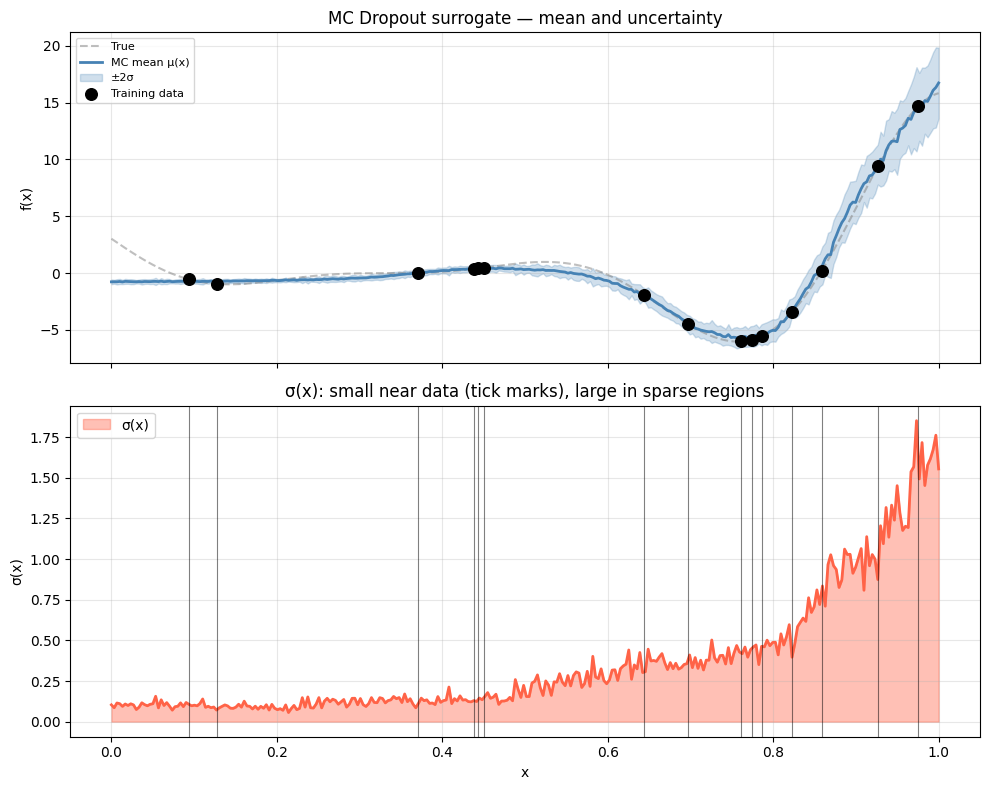

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(xs, y_true, color="gray", linestyle="--", linewidth=1.5, alpha=0.5, label="True")
axes[0].plot(xs, mu_mc, color="steelblue", linewidth=2, label="MC mean μ(x)")
axes[0].fill_between(xs, mu_mc-2*std_mc, mu_mc+2*std_mc,
                     alpha=0.25, color="steelblue", label="±2σ")
axes[0].scatter(X_np.squeeze(), y_np, color="black", s=70, zorder=5, label="Training data")
axes[0].set_ylabel("f(x)"); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[0].set_title("MC Dropout surrogate — mean and uncertainty")

axes[1].fill_between(xs, 0, std_mc, alpha=0.4, color="tomato", label="σ(x)")
axes[1].plot(xs, std_mc, color="tomato", linewidth=2)
for xi in X_np.squeeze():
    axes[1].axvline(xi, color="black", linewidth=0.8, alpha=0.5)
axes[1].set_ylabel("σ(x)"); axes[1].set_xlabel("x")
axes[1].set_title("σ(x): small near data (tick marks), large in sparse regions")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 4 — Training comparison: MC Dropout vs plain MLP

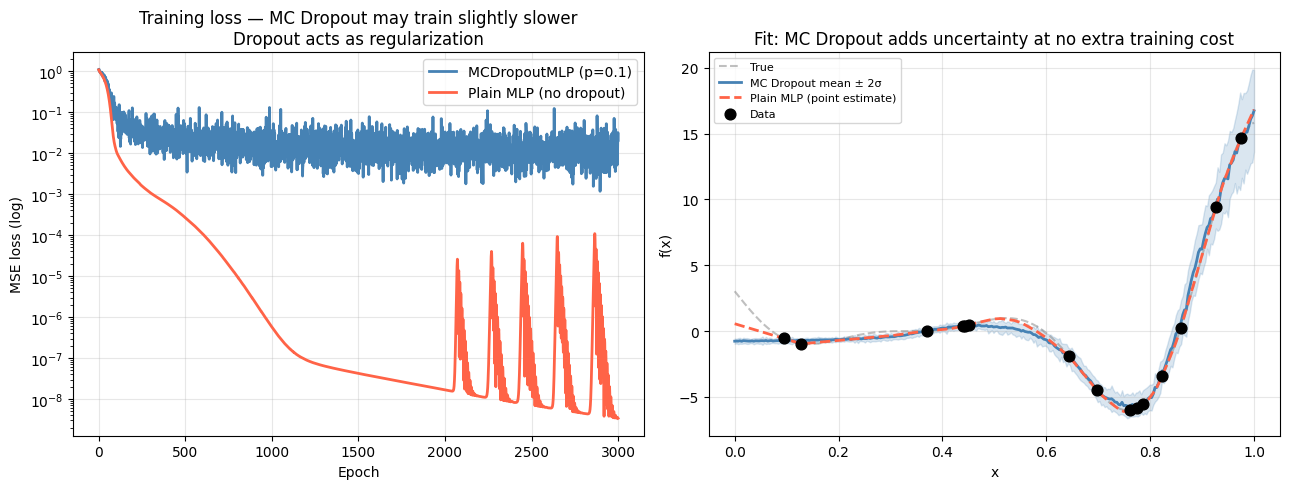

Final loss — MC Dropout: 0.02047  Plain MLP: 0.00000


In [7]:
torch.manual_seed(RANDOM_SEED)
model_plain = MLP()
losses_plain = train_model(model_plain, X_tr, y_tr, n_epochs=3000)

model_plain.eval()
with torch.no_grad():
    y_plain = model_plain(x_dense_t).squeeze().numpy() * ys + ym

epochs = np.arange(1, 3001)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogy(epochs, losses,       color="steelblue", linewidth=2, label="MCDropoutMLP (p=0.1)")
axes[0].semilogy(epochs, losses_plain, color="tomato",    linewidth=2, label="Plain MLP (no dropout)")
axes[0].set_title("Training loss — MC Dropout may train slightly slower\nDropout acts as regularization")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE loss (log)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(xs, y_true, color="gray", linestyle="--", linewidth=1.5, alpha=0.5, label="True")
axes[1].plot(xs, mu_mc, color="steelblue", linewidth=2, label="MC Dropout mean ± 2σ")
axes[1].fill_between(xs, mu_mc-2*std_mc, mu_mc+2*std_mc, alpha=0.2, color="steelblue")
axes[1].plot(xs, y_plain, color="tomato", linewidth=2, linestyle="--",
             label="Plain MLP (point estimate)")
axes[1].scatter(X_np.squeeze(), y_np, color="black", s=60, zorder=5, label="Data")
axes[1].set_title("Fit: MC Dropout adds uncertainty at no extra training cost")
axes[1].set_xlabel("x"); axes[1].set_ylabel("f(x)")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Final loss — MC Dropout: {losses[-1]:.5f}  Plain MLP: {losses_plain[-1]:.5f}")

## Part 5 — MC Dropout vs GP surrogate

Both give μ(x) and σ(x). The key differences:
- GP: exact Bayesian inference, O(n³) training, struggles in high dimensions
- MC Dropout: approximate, O(n·epochs) training, scales to high dimensions

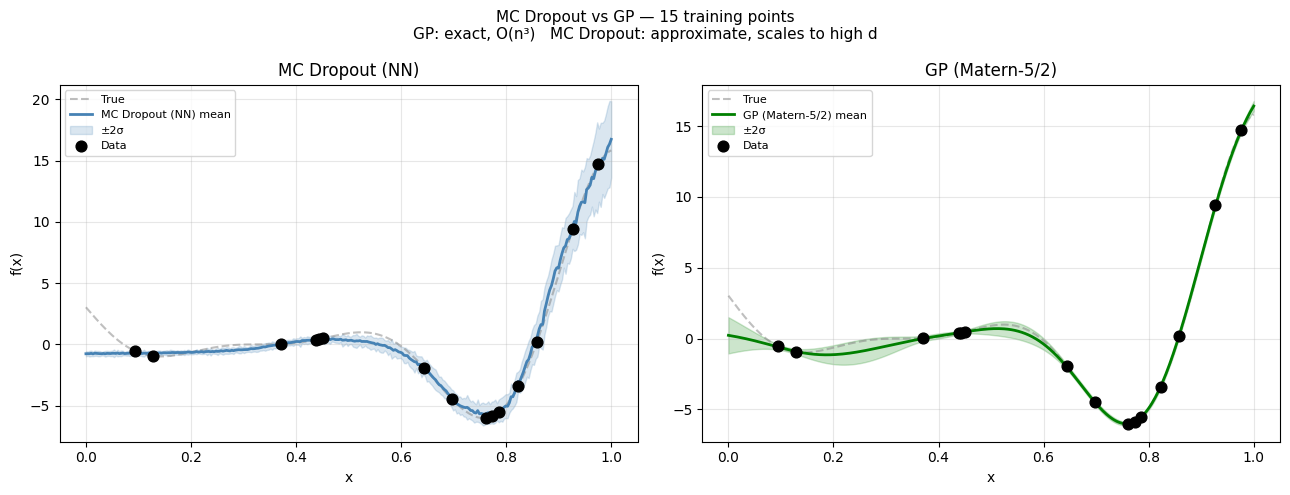

In [8]:
def matern52(X1, X2, length_scale=0.25, signal_var=4.0):
    X1 = np.atleast_2d(X1); X2 = np.atleast_2d(X2)
    diff = X1[:, None, :] - X2[None, :, :]
    r = np.sqrt(np.sum(diff**2, axis=-1))
    s = np.sqrt(5) * r / length_scale
    return signal_var * (1 + s + s**2/3) * np.exp(-s)

def gp_predict(X_tr, y_tr, X_test, noise=0.01):
    K    = matern52(X_tr, X_tr) + noise * np.eye(len(X_tr))
    Ks   = matern52(X_test, X_tr)
    Kss  = matern52(X_test, X_test)
    L    = np.linalg.cholesky(K)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_tr))
    mu   = Ks @ alpha
    v    = np.linalg.solve(L, Ks.T)
    std  = np.sqrt(np.maximum(np.diag(Kss) - np.sum(v**2, axis=0), 0))
    return mu, std

mu_gp, std_gp = gp_predict(X_np, y_np, x_dense.reshape(-1, 1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (mu, std, label, color) in zip(axes, [
    (mu_mc,  std_mc,  "MC Dropout (NN)",  "steelblue"),
    (mu_gp,  std_gp,  "GP (Matern-5/2)",  "green"),
]):
    ax.plot(xs, y_true, color="gray", linestyle="--", linewidth=1.5, alpha=0.5, label="True")
    ax.plot(xs, mu, color=color, linewidth=2, label=f"{label} mean")
    ax.fill_between(xs, mu-2*std, mu+2*std, alpha=0.2, color=color, label="±2σ")
    ax.scatter(X_np.squeeze(), y_np, color="black", s=60, zorder=5, label="Data")
    ax.set_title(label)
    ax.set_xlabel("x"); ax.set_ylabel("f(x)")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle(f"MC Dropout vs GP — {n_train} training points\n"
             "GP: exact, O(n³)   MC Dropout: approximate, scales to high d", fontsize=11)
plt.tight_layout()
plt.show()

## Part 6 — One BO step with MC Dropout

We plug MC Dropout directly into the BO loop. The acquisition function (EI) only sees μ and σ — it does not care whether they came from a GP or an NN.

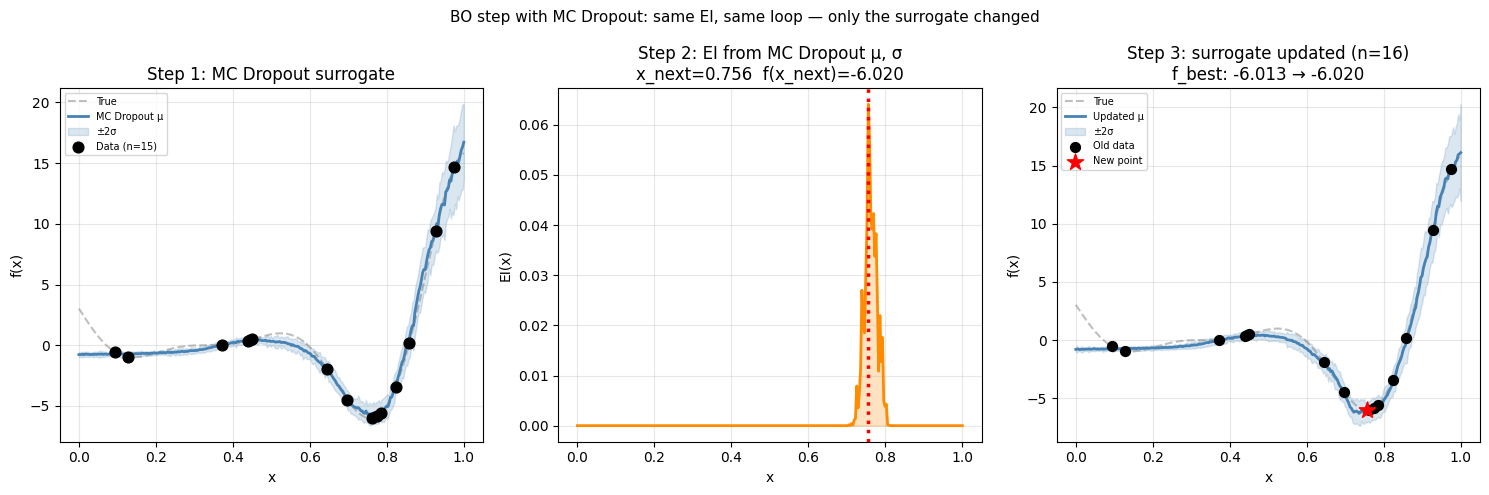

x_next = 0.7559   f(x_next) = -6.0197


In [11]:
# EI from MC Dropout μ and σ
f_best   = float(y_np.min())
ei_mc    = acq_ei(mu_mc, std_mc, f_best, xi=0.01)
idx_next = int(np.argmax(ei_mc))
x_next   = xs[idx_next]
y_next   = forrester(np.array([x_next])).item()

# Update and refit
X_new = np.vstack([X_np, [[x_next]]]).astype(np.float32)
y_new = np.append(y_np, y_next).astype(np.float32)
Xm2, Xs2 = float(X_new.mean()), float(X_new.std())
ym2, ys2 = float(y_new.mean()), float(y_new.std())
X_tr2 = to_tensor((X_new - Xm2) / Xs2)
y_tr2 = to_tensor((y_new - ym2) / ys2)

torch.manual_seed(RANDOM_SEED + 1)
model2 = MCDropoutMLP()
train_model(model2, X_tr2, y_tr2, n_epochs=3000)

x_dense_t2 = to_tensor((x_dense.reshape(-1, 1) - Xm2) / Xs2)
mu2_s, std2_s = model2.mc_predict(x_dense_t2)
mu2  = mu2_s.numpy() * ys2 + ym2
std2 = std2_s.numpy() * ys2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(xs, y_true, color="gray", linestyle="--", linewidth=1.5, alpha=0.5, label="True")
axes[0].plot(xs, mu_mc, color="steelblue", linewidth=2, label="MC Dropout μ")
axes[0].fill_between(xs, mu_mc-2*std_mc, mu_mc+2*std_mc, alpha=0.2, color="steelblue", label="±2σ")
axes[0].scatter(X_np.squeeze(), y_np, color="black", s=60, zorder=5, label=f"Data (n={n_train})")
axes[0].set_title("Step 1: MC Dropout surrogate")
axes[0].set_xlabel("x"); axes[0].set_ylabel("f(x)")
axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3)

axes[1].plot(xs, ei_mc, color="darkorange", linewidth=2)
axes[1].fill_between(xs, 0, ei_mc, alpha=0.25, color="darkorange")
axes[1].axvline(x_next, color="red", linewidth=2.5, linestyle=":")
axes[1].set_title(f"Step 2: EI from MC Dropout μ, σ\nx_next={x_next:.3f}  f(x_next)={y_next:.3f}")
axes[1].set_xlabel("x"); axes[1].set_ylabel("EI(x)")
axes[1].grid(True, alpha=0.3)

axes[2].plot(xs, y_true, color="gray", linestyle="--", linewidth=1.5, alpha=0.5, label="True")
axes[2].plot(xs, mu2, color="steelblue", linewidth=2, label="Updated μ")
axes[2].fill_between(xs, mu2-2*std2, mu2+2*std2, alpha=0.2, color="steelblue", label="±2σ")
axes[2].scatter(X_np.squeeze(), y_np, color="black", s=50, zorder=5, label="Old data")
axes[2].scatter([x_next], [y_next], color="red", s=150, zorder=6, marker="*", label="New point")
axes[2].set_title(f"Step 3: surrogate updated (n={len(X_new)})\n"
                  f"f_best: {f_best:.3f} → {float(y_new.min()):.3f}")
axes[2].set_xlabel("x"); axes[2].set_ylabel("f(x)")
axes[2].legend(fontsize=7); axes[2].grid(True, alpha=0.3)

plt.suptitle("BO step with MC Dropout: same EI, same loop — only the surrogate changed", fontsize=11)
plt.tight_layout()
plt.show()
print(f"x_next = {x_next:.4f}   f(x_next) = {y_next:.4f}")

## Summary

| Step | Code |
|---|---|
| Add dropout | `nn.Dropout(0.1)` after each `ReLU` |
| Keep dropout at inference | `model.train()` instead of `model.eval()` |
| Get μ and σ | `preds = [model(x) for _ in range(T)]`; `mu = mean(preds)`, `std = std(preds)` |
| Use in BO | Feed μ, σ into EI/LCB — same as GP |

**Advantage over GP:** O(n·epochs) training, no O(n³) kernel inversion, scales to high-dimensional inputs.

**Limitation:** approximate uncertainty — can be overconfident in regions far from training data.

**Next lesson:** Deep Ensembles — train 5 independent MLPs, compute mean/variance across them. Better calibrated uncertainty than MC Dropout, but 5× more training cost.